# 01 · From a curve to features, and PCA

*Compress many correlated numbers into a few meaningful ones.*

> ⏱ **Runtime:** ~20 s on a laptop CPU (no GPU) · 🎓 **Level:** beginner · 📊 **Data:** Al–Cu map + AFM grid

### 🎯 What you'll learn
1. what a **feature** and a **feature vector** are, and why we **standardise** them,
2. how **PCA** finds the directions that carry the most information,
3. how to read a **scree plot** and **loadings** to interpret those directions,
4. why PCA on the *whole curve* (64 numbers) sees more than PCA on one hardness value.

### 🧭 What you need to know first
- Notebook **00** (how to run cells; what the datasets are).
- The idea that each indent has a hardness `H` and modulus `E`.

### Step 0 — set-up

Run the cell below first. In Jupyter you run a cell by clicking it and pressing **Shift + Enter**.

> 🟢 **On Google Colab** this cell also clones the repo and installs a few extra packages — it takes about a minute the first time. On your own machine (after `pip install -r requirements.txt`) it's instant.

> ✅ **You should see:** a line like `helpers loaded from: .../mecanano_ml/__init__.py` — that means the helper package loaded correctly.

In [1]:
# --- Setup cell — run me first! ---------------------------------------------
# It makes the helper package `mecanano_ml` importable and sets a clean plot
# style. You do not need to understand every line here; just run it.
# On Google Colab it also clones the repo and installs the few extra packages
# Colab doesn't ship (takes ~1 min, once per session).
import os, sys, subprocess

def _find_src():
    # Look for the repo's src/ folder in the usual places (local clone / Colab).
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None

if "google.colab" in sys.modules:             # running on Colab -> set everything up
    # packages Colab does not preinstall (torch/sklearn/etc. are already there):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "hdbscan", "umap-learn", "pyts", "shap", "imbalanced-learn"],
                   check=False)

if _find_src() is None:                       # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)

sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))

import numpy as np                 # arrays and maths
import pandas as pd                # tables (each row = one indent)
import matplotlib.pyplot as plt    # plotting
import mecanano_ml as mm           # our tiny helper package: loaders + plotting
mm.set_style()                     # consistent, publication-like figures
# Confirm the helpers loaded (just the tail of the path, not your machine's folders).
_pkg = os.path.basename(os.path.dirname(mm.__file__))
print("helpers loaded from: .../" + _pkg + "/" + os.path.basename(mm.__file__))

helpers loaded from: .../mecanano_ml/__init__.py


In [2]:
# Two scikit-learn tools we'll use throughout this notebook:
from sklearn.decomposition import PCA               # Principal Component Analysis
from sklearn.preprocessing import StandardScaler    # z-scoring (standardisation)

## 1 · Warm-up: three scalar features

Start simple. Each Al–Cu indent gives hardness `H`, modulus `E` and their ratio
`H/E`. We will treat those three numbers as an indent's **features**.

> 🧠 **feature** — one measured number describing a sample. Here an indent has three features: `H`, `E`, `H/E`.

> 🧠 **feature vector** — the list of an indent's features stacked together, e.g. `[H, E, H/E]`. A dataset is then a table with one such vector per row.

These three features are **correlated** and live on **different scales** (GPa vs a
unitless ratio). Distance- and variance-based methods (PCA, clustering) are misled
by scale, so we **standardise** first.

> 🧠 **standardise (z-score)** — rescale a feature so it has mean 0 and standard deviation 1: subtract the mean, divide by the spread. Now every feature counts equally, regardless of its units.

> ✅ **When you run the next cell, you should see:** the raw means/stds (very different across features), then all means ≈ 0 and stds ≈ 1 after standardising.

In [3]:
df = mm.load_map("alcu_2um")          # the Al–Cu map as a table
feat = ["H", "E", "HE"]               # the three features we'll use
X = df[feat].values                   # a (40000, 3) array: one row per indent
print("raw means:", X.mean(0).round(2), " raw stds:", X.std(0).round(2))

# StandardScaler learns each column's mean & std, then applies (x - mean) / std.
Xs = StandardScaler().fit_transform(X)
print("after z-score -> mean 0, std 1:", Xs.mean(0).round(2), Xs.std(0).round(2))

raw means: [3.980e+00 8.845e+01 4.000e-02]  raw stds: [1.710e+00 1.404e+01 1.000e-02]
after z-score -> mean 0, std 1: [ 0.  0. -0.] [1. 1. 1.]


> ✅ **When you run the next cell, you should see:** a 3×3 correlation table. Values near ±1 mean two features move together; that redundancy is exactly what PCA will compress.

In [4]:
# How correlated are the three features? np.corrcoef wants variables in rows,
# so we transpose (.T). Diagonal is 1 (each feature with itself).
print(pd.DataFrame(np.corrcoef(Xs.T), index=feat, columns=feat).round(2))

       H     E    HE
H   1.00  0.84  0.95
E   0.84  1.00  0.66
HE  0.95  0.66  1.00


Because `H`, `E`, `H/E` are correlated, most of their variation really lives on
**one or two directions** — precisely what PCA will expose.

> 🧠 **variance** — how spread out the numbers are. PCA looks for the directions along which the data varies the most, because that is where the useful structure usually lives.

> 🧠 **PCA (Principal Component Analysis)** — a rotation of the data onto new axes (the *principal components*) ordered by how much variance each captures. PC1 is the single most informative direction.

> ✅ **When you run the next cell, you should see:** the explained-variance ratio (PC1 dominates) and a scatter of PC1 vs PC2 that already splits into **two clouds** = two phases.

explained variance ratio: [0.879 0.118 0.002]


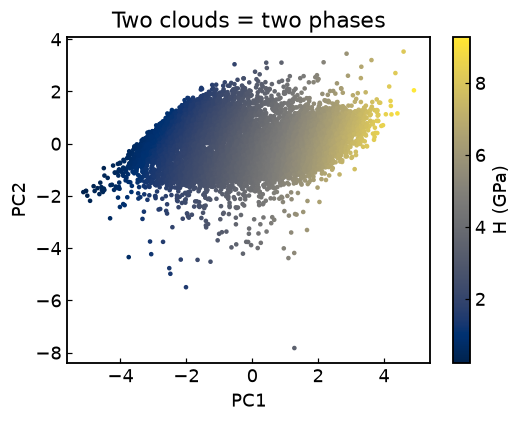

In [5]:
p = PCA().fit(Xs)                                   # learn the principal components
print("explained variance ratio:", p.explained_variance_ratio_.round(3))
scores = p.transform(Xs)                            # each indent's coordinates on the new axes

fig, ax = plt.subplots(figsize=(5, 4))
# Colour each point by its true hardness so we can see PC1 tracks it.
sctr = ax.scatter(scores[:, 0], scores[:, 1], c=df["H"], s=4, cmap="cividis")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.colorbar(sctr, label="H (GPa)"); ax.set_title("Two clouds = two phases"); fig.tight_layout()

*🖼 **Figure.** Every point is one indent, placed by its first two principal components and coloured by hardness. Two separated clouds = the two phases, found without ever telling the algorithm they exist.*

The **loadings** tell us what the new axes *mean* in terms of the original features.

> 🧠 **loading** — the recipe of a principal component: how much each original feature contributes to it. Big loading = that feature drives the axis.

> ✅ **When you run the next cell, you should see:** a small table: PC1 loads on overall H/E magnitude; PC2 captures the H-vs-E contrast.

In [6]:
# components_ has one row per PC; take the first two and label by feature.
load = pd.DataFrame(p.components_[:2].T, index=feat, columns=["PC1", "PC2"]).round(2)
print(load)
print("\nPC1 ~ overall hardness/stiffness magnitude; PC2 ~ the H/E contrast.")

     PC1   PC2
H   0.61 -0.14
E   0.54  0.79
HE  0.57 -0.60

PC1 ~ overall hardness/stiffness magnitude; PC2 ~ the H/E contrast.


## 2 · The real power: PCA on the *whole curve*

A single hardness number throws away the **shape** of the indentation response. The
AFM grid keeps the full **hardness-vs-depth curve** (64 points per indent). PCA turns
those 64 correlated numbers into a handful of meaningful components.

> ✅ **When you run the next cell, you should see:** the curve matrix shape (about 800 × ~60 kept depth points) and the depth range in nm.

In [7]:
from sklearn.impute import SimpleImputer            # fills in missing values

afm = mm.load_afm_grid()
C = afm["H_curve"].copy()                           # (n_indents, 64) hardness curves
depth = afm["depth_nm"]

# Real curves miss a few depth points near the noisy surface. Keep only depth
# channels that are present for most indents, then fill the rest with the median
# so we can keep every indent (no row is dropped).
keep = np.isfinite(C).mean(0) > 0.5                 # columns finite in >50% of indents
C, depth = C[:, keep], depth[keep]
C = SimpleImputer(strategy="median").fit_transform(C)
print("curve matrix:", C.shape, " depth:", f"{depth[0]:.0f}-{depth[-1]:.0f} nm")

Cs = StandardScaler().fit_transform(C)              # standardise each depth channel

curve matrix: (800, 55)  depth: 7-103 nm


> 🧠 **scree plot** — the % of variance each component explains, in order. It shows how few components you need — the curve usually drops steeply then flattens (the 'elbow').

> ✅ **When you run the next cell, you should see:** left: a scree plot where the first ~3 components already explain most of the variance; right: what those components look like along the curve.

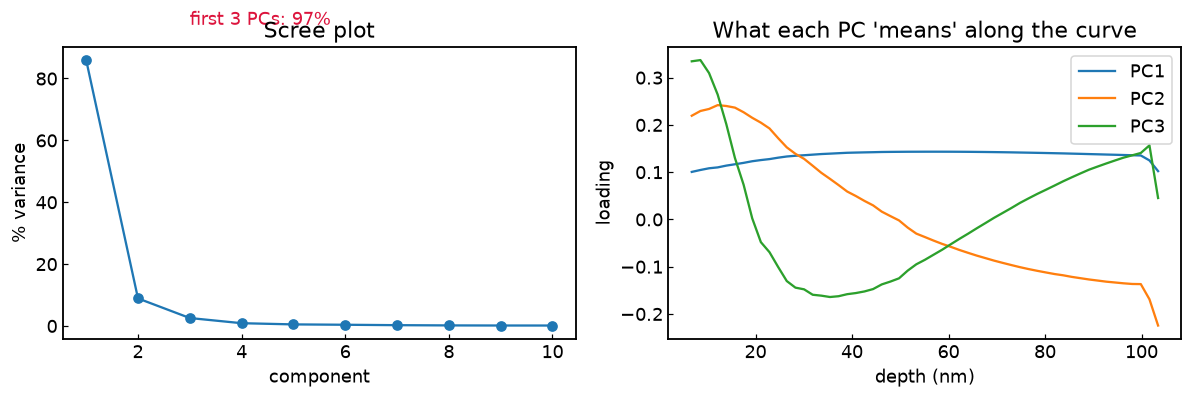

In [8]:
pc = PCA(n_components=10).fit(Cs)                    # keep the top 10 components

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
# --- scree plot: variance explained per component ---
ax[0].plot(np.arange(1, 11), pc.explained_variance_ratio_ * 100, "o-")
ax[0].set_xlabel("component"); ax[0].set_ylabel("% variance"); ax[0].set_title("Scree plot")
cum = np.cumsum(pc.explained_variance_ratio_) * 100
ax[0].text(3, cum[2], f"first 3 PCs: {cum[2]:.0f}%", color="crimson")
# --- loadings: what each of the first 3 PCs 'means' along the depth axis ---
for i in range(3):
    ax[1].plot(depth, pc.components_[i], label=f"PC{i+1}")
ax[1].set_xlabel("depth (nm)"); ax[1].set_ylabel("loading"); ax[1].legend()
ax[1].set_title("What each PC 'means' along the curve"); fig.tight_layout()

*🖼 **Figure.** Left: the first few components capture most of the variance — the curve compresses well. Right: PC1 is a roughly flat offset (overall hardness level), higher PCs capture how the curve bends with depth.*

> ✅ **When you run the next cell, you should see:** a 2-D scatter of the curves in PC space, again coloured by hardness — the few PC scores are what you feed to clustering next.

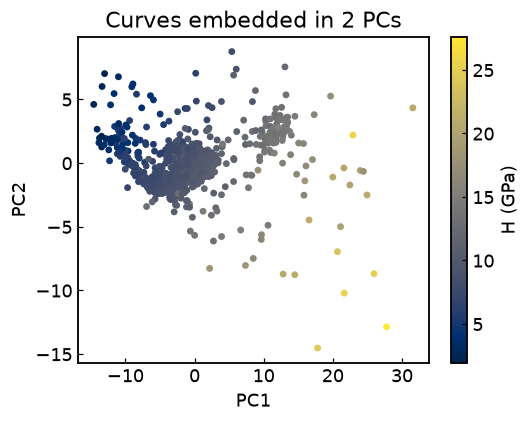

In [9]:
scores = pc.transform(Cs)                           # each curve's coordinates in PC space
fig, ax = plt.subplots(figsize=(5, 4))
s = ax.scatter(scores[:, 0], scores[:, 1], c=afm["H"], s=12, cmap="cividis")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); plt.colorbar(s, label="H (GPa)")
ax.set_title("Curves embedded in 2 PCs"); fig.tight_layout()

## 3 · Non-linear embeddings (t-SNE / UMAP)

PCA is **linear** — it can only rotate and stretch. When structure is curved, **t-SNE**
and **UMAP** can lay it out more clearly, at the cost of interpretable axes.

> 🧠 **embedding** — a low-dimensional (usually 2-D) layout of high-dimensional data, made so that similar samples land near each other. Great for *looking*; distances are not physically meaningful.

> ⚠️ Use t-SNE/UMAP to **look**, not to measure. The axes have no units and the gaps
> between clusters are not to scale.

> ✅ **When you run the next cell, you should see:** one or two panels (t-SNE, and UMAP if installed) showing the curves grouped by hardness. This is the slowest cell — give it ~15 s.

<venv>\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<tmp>\ipykernel_42648\846999538.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.colorbar(sc, ax=ax[0].tolist(), label="H (GPa)"); fig.tight_layout()


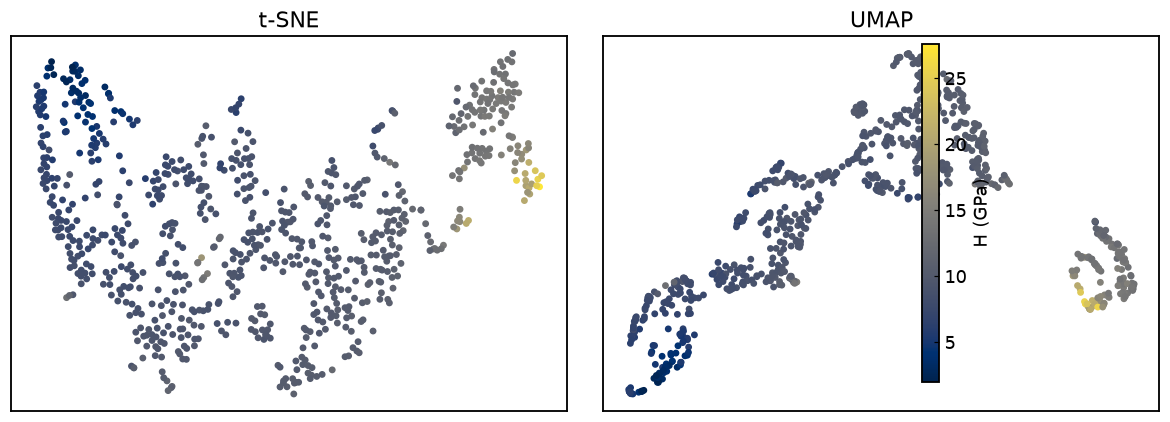

In [10]:
from sklearn.manifold import TSNE

# t-SNE on the first 5 PC scores (feeding PCA scores keeps it fast and denoised).
emb = {"t-SNE": TSNE(n_components=2, init="pca", perplexity=30,
                     random_state=0).fit_transform(scores[:, :5])}
try:
    import umap                                      # UMAP is optional
    emb["UMAP"] = umap.UMAP(n_components=2, random_state=0).fit_transform(scores[:, :5])
except Exception as e:
    print("UMAP not installed — skipping (pip install umap-learn):", type(e).__name__)

fig, ax = plt.subplots(1, len(emb), figsize=(5.4 * len(emb), 4), squeeze=False)
for a, (name, Z) in zip(ax[0], emb.items()):
    sc = a.scatter(Z[:, 0], Z[:, 1], c=afm["H"], s=12, cmap="cividis")
    a.set_title(name); a.set_xticks([]); a.set_yticks([])
fig.colorbar(sc, ax=ax[0].tolist(), label="H (GPa)"); fig.tight_layout()

*🖼 **Figure.** The same indents, laid out by t-SNE/UMAP. Points of similar hardness cluster together — a quick visual confirmation that the curves carry clean phase structure.*

### ✅ Self-check
A quick sanity test that the numbers above came out sensible. If you edit the notebook and a result drifts badly, the cell below will stop with an `AssertionError` — a helpful early warning, not a bug.

In [11]:
# Each line fails loudly if a key result drifts out of a sensible range.
# (These also run in CI, so a broken result fails the build.)
assert p.explained_variance_ratio_[0] > 0.7, "PC1 should dominate the 3 scalar features"
assert scores.shape[1] == 10, "we kept 10 curve components"
assert "t-SNE" in emb, "the t-SNE embedding should have been computed"
print("self-check passed ✓ — PCA captured the structure")

self-check passed ✓ — PCA captured the structure


## ✅ Recap
- **Standardise** before PCA/clustering, or GPa-scale features drown a unitless ratio.
- **PCA** rotates to the directions of greatest variance; the **scree plot** says how many to keep and the **loadings** say what they mean.
- PCA on the **whole curve** keeps shape information that a single hardness value discards — those few scores feed notebook 02.

## 🔧 Try it yourself
Small changes teach the most. Try these (re-run the cell after each):
1. Change `PCA(n_components=10)` to `n_components=3` and re-run the scree cell. Do the first three components change?
2. In the t-SNE cell, set `perplexity=5` then `perplexity=50` — how does the layout change? (Perplexity ≈ how many neighbours each point 'trusts'.)
3. Feed raw features instead of PCA scores to t-SNE (`Xs` from Section 1). Is it faster or slower?

## 🩹 Common errors & fixes
- **`ValueError: Input contains NaN`** → a curve had missing points; make sure you ran the impute cell in Section 2 before the PCA.
- **t-SNE is slow / perplexity error** → perplexity must be smaller than the number of points; keep it ≤ 50 here.
- **UMAP line prints 'not installed'** → that's fine, the notebook still works; `pip install umap-learn` to enable it.

---
**Next:** open **`02_clustering_phases.ipynb`** — turn these components into a phase map.